In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import os
import hashlib
from pathlib import Path
from dotenv import load_dotenv

pd.options.display.max_columns = 50

In [2]:
# === ENV SETUP (MUST BE FIRST CELL) ===

# Force-load .env from the project root (cwd)
env_path = Path.cwd() / ".env"
load_dotenv(dotenv_path=env_path)

print("Loaded .env from:", env_path)
print("PSEUDO_SALT present:", bool(os.environ.get("PSEUDO_SALT")))

if not os.environ.get("PSEUDO_SALT"):
    raise RuntimeError(
        "PSEUDO_SALT not found. Ensure .env is in the project root and Jupyter "
        "was started via `uv run jupyter lab`."
    )

Loaded .env from: /home/drcjar/usc-times/.env
PSEUDO_SALT present: True


In [3]:
# ---- load salt ----
SALT = os.environ.get("PSEUDO_SALT")
if not SALT:
    raise RuntimeError(
        "Missing PSEUDO_SALT. Set it in your shell or a local .env (never commit it)."
    )

# ---- derive a fixed-length key (32 bytes) from the salt ----
# This allows arbitrarily long salts while respecting blake2b key length limits.
KEY = hashlib.sha256(SALT.encode("utf-8")).digest()  # 32 bytes

def pseudonymise_id(series: pd.Series, key: bytes, out_len: int = 16) -> pd.Series:
    """
    Stable, non-reversible pseudonymous ID using keyed BLAKE2b.
    - Accepts arbitrarily long SALT (we pre-hash it into KEY)
    - out_len controls displayed length, not security
    """
    s = series.astype("string").str.strip()

    def _hash_one(x):
        if pd.isna(x) or x == "" or str(x).lower() == "nan":
            return pd.NA
        h = hashlib.blake2b(
            str(x).encode("utf-8"),
            key=key,
            digest_size=16,   # 16 bytes -> 32 hex chars
        ).hexdigest()
        return f"p_{h[:out_len]}"

    return s.apply(_hash_one)

def apply_pseudonymisation(df_in: pd.DataFrame, id_col: str, new_col: str = "patient_id") -> pd.DataFrame:
    df_out = df_in.copy()
    if id_col not in df_out.columns:
        raise KeyError(f"Expected column '{id_col}' not found.")
    df_out[new_col] = pseudonymise_id(df_out[id_col], KEY)
    df_out = df_out.drop(columns=[id_col])
    return df_out

In [4]:
# clean sheets, throw away top two rows and unecessary identifiers
def cleandf(df):
    df = (
    df.iloc[1:]
      .rename(columns=df.iloc[1])
      .iloc[1:]
      .reset_index(drop=True)
    )
    # Drop obvious direct/indirect identifiers (raw data stays local)
    df = df.drop(columns=[
        "Patient_Name", "DOB", "GP_Address", "GP_Practice_Code", "Registered_GP_Practice",
        "CareId"
    ], errors="ignore")
    return df

# Table 1

# -------------------------
# Config
# -------------------------
CONT_VARS = ["Age"]

REFERRAL_SOURCE_MAP = {
    "General Medical Practitioner": "General Medical Practitioner",
    "Consultant, other than in an Emergency Care Department": "Consultant",
    "Emergency Care Department (inc MIUs, Walk In Centres & Urgent Treatment Centres)": "A&E Consultant",
    "Following emergency admission": "Following emergency admission",
    "Other - Consultant responsible for OPA": "Consultant",
}

VAR_LABELS = {
    "OPReferralSource_collapsed": "Referral Source",
    "CancerStatus_collapsed": "Cancer status",
}

CAT_VARS = ["OPReferralSource_collapsed", "CancerStatus_collapsed"]

# Explicit order for categorical variables in Table 1
CAT_VAR_ORDER = ["Referral Source", "Cancer status"]  # <-- controls section order

# -------------------------
# Helpers
# -------------------------
def summarize_continuous(series):
    s = pd.to_numeric(series, errors="coerce")
    return pd.Series({
        "Mean (SD)": f"{s.mean():.1f} ({s.std():.1f})",
        "Median (IQR)": f"{s.median():.1f} ({s.quantile(0.25):.1f}–{s.quantile(0.75):.1f})"
    })

def summarize_categorical(series):
    s = series.fillna("Missing").astype(str).value_counts(dropna=False)
    pct = (s / s.sum() * 100).round(1)
    return (s.astype(int).astype(str) + " (" + pct.astype(str) + "%)")
    
def dedupe_variable_labels(t: pd.DataFrame) -> pd.DataFrame:
    t = t.copy()
    t["Variable"] = t["Variable"].where(t["Variable"].ne(t["Variable"].shift()), "")
    return t

def sort_categories_within_variable(cat_long: pd.DataFrame) -> pd.DataFrame:
    return (
        cat_long
        .assign(_n=lambda d: d["Value"].astype(str).str.extract(r"^(\d+)").astype(float))
        .sort_values(["Variable", "_n"], ascending=[True, False])
        .drop(columns="_n")
    )

def enforce_variable_order(cat_long: pd.DataFrame, order: list[str]) -> pd.DataFrame:
    """Force the order of Variable blocks (e.g., Referral Source then Cancer status)."""
    out = cat_long.copy()
    out["_var_order"] = pd.Categorical(out["Variable"], categories=order, ordered=True)
    out = out.sort_values(["_var_order"]).drop(columns="_var_order")
    return out

def build_cont_long(df_in: pd.DataFrame, cont_vars: list[str]) -> pd.DataFrame:
    rows = []
    for v in cont_vars:
        stats = summarize_continuous(df_in[v])
        rows.extend([
            {"Variable": v, "Category": "Mean (SD)", "Value": stats["Mean (SD)"]},
            {"Variable": v, "Category": "Median (IQR)", "Value": stats["Median (IQR)"]},
        ])
    return pd.DataFrame(rows)

def build_cat_long(df_in: pd.DataFrame, cat_vars: list[str], var_labels: dict[str, str] | None = None) -> pd.DataFrame:
    blocks = []
    for v in cat_vars:
        s = summarize_categorical(df_in[v])
        blocks.append(pd.DataFrame({
            "Variable": v,
            "Category": s.index.astype(str),
            "Value": s.values
        }))
    out = pd.concat(blocks, ignore_index=True) if blocks else pd.DataFrame(columns=["Variable","Category","Value"])
    if var_labels:
        out["Variable"] = out["Variable"].replace(var_labels)
    return out

def add_collapsed_vars(df_in: pd.DataFrame) -> pd.DataFrame:
    df_out = df_in.copy()

    if "OPReferralSource" in df_out.columns:
        df_out["OPReferralSource_collapsed"] = (
            df_out["OPReferralSource"].map(REFERRAL_SOURCE_MAP).fillna("Other/Unknown")
        )

    if "CancerStatus" in df_out.columns:
        status = df_out["CancerStatus"].fillna("")
        df_out["CancerStatus_collapsed"] = np.where(
            status.str.contains("No new cancer diagnosis identified", case=False, na=False),
            "No new cancer identified",
            "Cancer identified"
        )

    return df_out

def make_table1(df_in: pd.DataFrame) -> pd.DataFrame:
    df2 = add_collapsed_vars(df_in)

    cont_long = build_cont_long(df2, CONT_VARS)

    cat_vars_present = [v for v in CAT_VARS if v in df2.columns]
    cat_long = build_cat_long(df2, cat_vars_present, var_labels=VAR_LABELS)

    # sort within each variable by n (descending)
    cat_long = sort_categories_within_variable(cat_long)

    # THEN enforce block order: Referral Source first, Cancer status second
    cat_long = enforce_variable_order(cat_long, CAT_VAR_ORDER)

    spacer = pd.DataFrame([{"Variable": "", "Category": "", "Value": ""}])

    table1 = pd.concat(
        [
            pd.DataFrame([{"Variable": "", "Category": "", "Value": ""}]),
            cont_long,
            spacer,
            pd.DataFrame([{"Variable": "", "Category": "", "Value": ""}]),
            cat_long,
        ],
        ignore_index=True
    )

    return dedupe_variable_labels(table1)


# cancer pickup by referral source
import pandas as pd
import numpy as np

def cancer_yield_by_referral_source(
    df: pd.DataFrame,
    referral_col: str = "OPReferralSource",
    cancer_col: str = "CancerStatus",
    referral_map: dict | None = None,
    include_missing: bool = False,
) -> pd.DataFrame:
    """
    Return a tidy table of Cancer identified by Referral source as n (row %),
    sorted by percentage descending.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    referral_col : str
        Column containing referral source.
    cancer_col : str
        Column containing cancer status text.
    referral_map : dict, optional
        Mapping to collapse referral sources.
    include_missing : bool
        Whether to include 'Missing' referral sources.

    Returns
    -------
    pd.DataFrame
        Columns: ['Referral source', 'Cancer N (%)']
    """

    df2 = df.copy()

    # -------------------------
    # Collapse referral source
    # -------------------------
    if referral_map is None:
        referral_map = {}

    df2["Referral_source_collapsed"] = (
        df2[referral_col]
        .map(referral_map)
        .fillna("Other/Unknown")
    )

    # -------------------------
    # Collapse cancer status
    # -------------------------
    status = df2[cancer_col].fillna("")
    df2["Cancer_status_collapsed"] = np.where(
        status.str.contains("No new cancer diagnosis identified", case=False, na=False),
        "No new cancer identified",
        "Cancer identified"
    )

    # -------------------------
    # Crosstab (row %)
    # -------------------------
    tmp = df2.assign(
        Referral_source=df2["Referral_source_collapsed"].fillna("Missing"),
        Cancer_status=df2["Cancer_status_collapsed"].fillna("Missing"),
    )

    ct_counts = pd.crosstab(tmp["Referral_source"], tmp["Cancer_status"])
    ct_row_pct = pd.crosstab(
        tmp["Referral_source"],
        tmp["Cancer_status"],
        normalize="index"
    ) * 100

    ct_pretty = (
        ct_counts.astype(int).astype(str)
        + " ("
        + ct_row_pct.round(1).astype(str)
        + "%)"
    )

    # -------------------------
    # Long format + filter
    # -------------------------
    out = (
        ct_pretty
        .reset_index()
        .melt(
            id_vars="Referral_source",
            var_name="Cancer status",
            value_name="Cancer N (%)"
        )
        .rename(columns={"Referral_source": "Referral source"})
        .query("`Cancer status` == 'Cancer identified'")
        .assign(
            pct=lambda d: d["Cancer N (%)"]
            .str.extract(r"\(([\d\.]+)%\)")
            .astype(float)
        )
        .sort_values("pct", ascending=False)
        .drop(columns=["Cancer status", "pct"])
        .reset_index(drop=True)
    )

    if not include_missing:
        out = out[out["Referral source"] != "Missing"]

    return out

In [5]:
"""
What I would really wish to do is show that the USC Lung SOP (officially implemented 8.8.25)  is helpful in terms of:

     1.Reducing time from ReferralReceivedDate to CT Thorax date
     2.Reducing time from ReferralReceivedDate to Cancer Faster Diagnosis Pathway End Date[1] - target 75%, 80% from March 2026
     3.Reducing the number of appointments between ReferralReceivedDate and Cancer Faster Diagnosis Pathway End Date
     4.Reducing the number of blood tests and scans between ReferralReceivedDate and Cancer Faster Diagnosis Pathway End Date
     5.Reducing the number proportion of CT Thorax performed which are low dose non-contrast CT Thorax (reducing patient radiation and contrast exposure, saving staff time, saving cost of contrast)


    A. Would you be able to share data for a slightly longer period, say six months, June 2025-December 2026, with the additional variable  Cancer Faster Diagnosis Pathway End Date? 
    B. I am very comfortable handling raw structured tabular data, could you share for a given set of NHS Numbers (identified in A)  details of appointments, blood tests, and radiology results, between a given set of dates (ReferralReceivedDate and Cancer Faster Diagnosis Pathway End Date for each NHS Number)?

"""

'\nWhat I would really wish to do is show that the USC Lung SOP (officially implemented 8.8.25)  is helpful in terms of:\n\n     1.Reducing time from ReferralReceivedDate to CT Thorax date\n     2.Reducing time from ReferralReceivedDate to Cancer Faster Diagnosis Pathway End Date[1] - target 75%, 80% from March 2026\n     3.Reducing the number of appointments between ReferralReceivedDate and Cancer Faster Diagnosis Pathway End Date\n     4.Reducing the number of blood tests and scans between ReferralReceivedDate and Cancer Faster Diagnosis Pathway End Date\n     5.Reducing the number proportion of CT Thorax performed which are low dose non-contrast CT Thorax (reducing patient radiation and contrast exposure, saving staff time, saving cost of contrast)\n\n\n    A. Would you be able to share data for a slightly longer period, say six months, June 2025-December 2026, with the additional variable  Cancer Faster Diagnosis Pathway End Date? \n\u2002\u2002\u2002\u2002B. I am very comfortable 

In [6]:
df = pd.read_excel("CR_DM_20260127_Lung_Cancer_SOP_Audit v3.xlsx", sheet_name=None)

In [7]:
df.keys() # these are our sheets

dict_keys(['Cover', 'Cancer Pathways', 'OP Attendances', 'Radiology', 'Radiology 3m before Pathway', 'Radiology 3m after Pathway', 'Bloods', 'SQL_Pathways', 'SQL_OPA', 'SQL_Radiology', 'SQL_Bloods'])

In [8]:
cp = cleandf(df['Cancer Pathways'])
op = cleandf(df['OP Attendances'])
rad = cleandf(df['Radiology'])
blood = cleandf(df['Bloods'])
# Pseudonymise and drop direct identifiers before any analysis
cp = apply_pseudonymisation(cp, id_col='NHS_Number', new_col='patient_id')
op = apply_pseudonymisation(op, id_col='NHS_Number', new_col='patient_id')
rad = apply_pseudonymisation(rad, id_col='NHS_Number', new_col='patient_id')
blood = apply_pseudonymisation(blood, id_col='NHS_Number', new_col='patient_id')

In [9]:
print(cp['patient_id'].nunique()) # number of unique NHS Numbers on a cancer pathway
print(op['patient_id'].nunique()) # number of unique NHS Numbers with an OP appointment
print(rad['patient_id'].nunique()) # number of unique NHS Numbers with radiology
print(blood['patient_id'].nunique()) # number of unique NHS Numbers with bloods

284
266
168
113


In [10]:
df = cp

In [11]:
df['CancerStatus'].value_counts()

CancerStatus
No new cancer diagnosis identified by the Health Care Provider                    227
First NHS funded treatment commenced                                               47
Subsequent NHS funded treatment commenced                                           4
Diagnosis of new cancer confirmed - subsequent NHS funded treatment planned         4
Suspected Primary Cancer                                                            3
Diagnosis of new cancer confirmed - no NHS funded treatment planned                 3
Diagnosis of new cancer confirmed - NHS funded first treatment not yet planned      2
Recurrent cancer NHS funded treatment commenced                                     1
Name: count, dtype: int64

In [12]:
table1 = make_table1(df)
display(
    table1
    .style
    .hide(axis="index")
)

Variable,Category,Value
,,
Age,Mean (SD),63.1 (13.9)
,Median (IQR),63.0 (53.0–74.0)
,,
,,
Referral Source,General Medical Practitioner,138 (47.4%)
,Consultant,119 (40.9%)
,A&E Consultant,23 (7.9%)
,Following emergency admission,11 (3.8%)
Cancer status,No new cancer identified,227 (78.0%)


In [13]:
REFERRAL_SOURCE_MAP = {
    "General Medical Practitioner": "General Medical Practitioner",
    "Consultant, other than in an Emergency Care Department": "Consultant",
    "Emergency Care Department (inc MIUs, Walk In Centres & Urgent Treatment Centres)": "A&E Consultant",
    "Following emergency admission": "Following emergency admission",
    "Other - Consultant responsible for OPA": "Consultant",
}

ct_long_clean = cancer_yield_by_referral_source(
    df,
    referral_map=REFERRAL_SOURCE_MAP
)

display(
    ct_long_clean
    .style
    .hide(axis="index")
)

Referral source,Cancer N (%)
Following emergency admission,10 (90.9%)
Consultant,29 (24.4%)
General Medical Practitioner,22 (15.9%)
A&E Consultant,3 (13.0%)


In [14]:
df['FDS_Pathway_End_Date'].isnull().value_counts()

FDS_Pathway_End_Date
False    287
True       4
Name: count, dtype: int64

In [15]:
df[df['FDS_Pathway_End_Date'].isnull()] # these should be checked but likely relate to patients whose FDS hasn't ended yet

df = df.dropna(subset=["FDS_Pathway_End_Date"]) # we drop ones with no end date

In [16]:
df['ReferralReceivedDate'].min() # first ref

'2025-06-02 00:00:00'

In [17]:
df['ReferralReceivedDate'].max() # last ref - we've 6/12 window

'2025-12-31 00:00:00'

In [18]:
df[df['ReferralReceivedDate'] == df['ReferralReceivedDate'].max()]['FDS_Pathway_End_Date'] # FDS_Pathway_End_Date can be outside 6/12 window

288    2026-01-19 00:00:00.000
289    2026-01-21 00:00:00.000
290    2025-12-31 00:00:00.000
Name: FDS_Pathway_End_Date, dtype: object

In [19]:
df['ReferralReceivedDate'].isnull().value_counts()

ReferralReceivedDate
False    287
Name: count, dtype: int64

In [20]:
"""
# don't want right-censoring bias - actually not a problem since we're looking at complete pathways only
last_referral_date = df["ReferralReceivedDate"].max()
cutoff_date = last_referral_date - pd.Timedelta(days=14)
df = df[
    (df["ReferralReceivedDate"] <= cutoff_date)
].copy()

len(df)
"""

'\n# don\'t want right-censoring bias - actually not a problem since we\'re looking at complete pathways only\nlast_referral_date = df["ReferralReceivedDate"].max()\ncutoff_date = last_referral_date - pd.Timedelta(days=14)\ndf = df[\n    (df["ReferralReceivedDate"] <= cutoff_date)\n].copy()\n\nlen(df)\n'

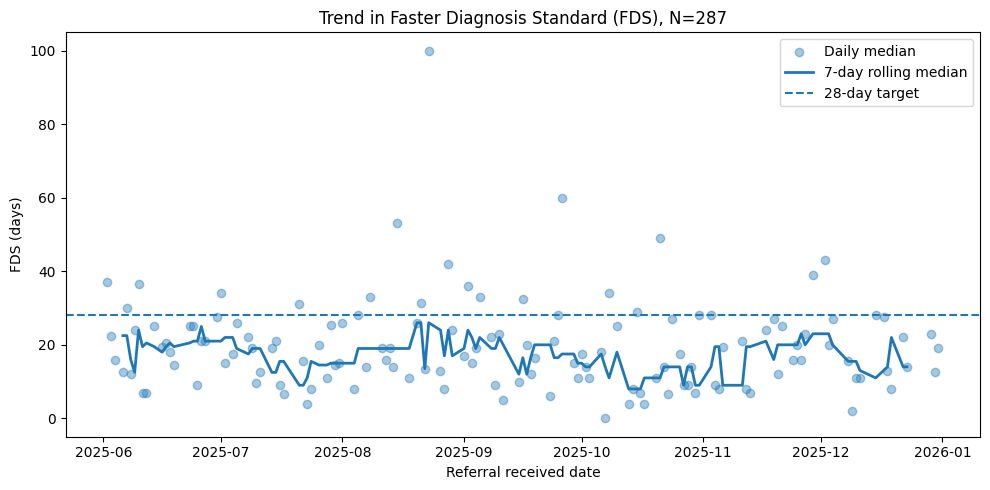

In [21]:
df = df.copy()

df["FDS_Pathway_End_Date"] = pd.to_datetime(
    df["FDS_Pathway_End_Date"],
    errors="coerce"
)
df["ReferralReceivedDate"] = pd.to_datetime(
    df["ReferralReceivedDate"],
    errors="coerce"
)

df = df.copy()
df['FDS_days'] = df['FDS_Pathway_End_Date'] - df['ReferralReceivedDate']

df['FDS_days'] = (
    df['FDS_days'].dropna().astype(str)
    .str.replace(' days', '', regex=False)
    .astype(int)
)

daily = (
    df.groupby('ReferralReceivedDate')['FDS_days']
      .median()
      .sort_index()
)

rolling = daily.rolling(window=7, center=True).median()  # 7-day smoothing

plt.figure(figsize=(10,5))
plt.scatter(daily.index, daily.values, alpha=0.4, label='Daily median')
plt.plot(rolling.index, rolling.values, linewidth=2, label='7-day rolling median')
plt.axhline(28, linestyle='--', label='28-day target')

plt.ylabel('FDS (days)')
plt.xlabel('Referral received date')
plt.title('Trend in Faster Diagnosis Standard (FDS), N={}'.format(len(df)))
plt.legend()
plt.tight_layout()

plt.savefig(
    'trend_in_fds1.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


In [22]:
(df['FDS_days'] > 28).value_counts(normalize=True)

FDS_days
False    0.787456
True     0.212544
Name: proportion, dtype: float64

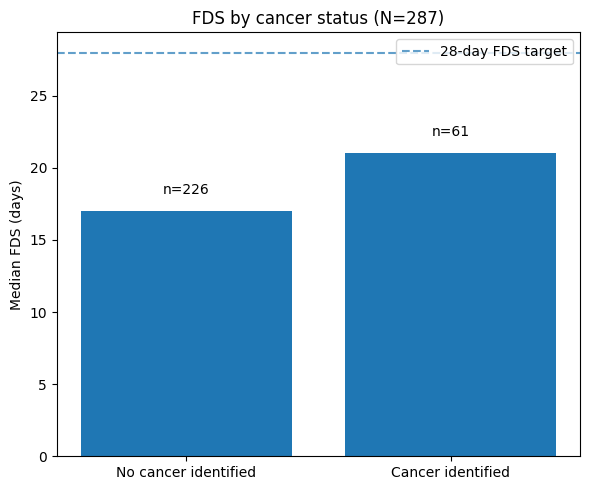

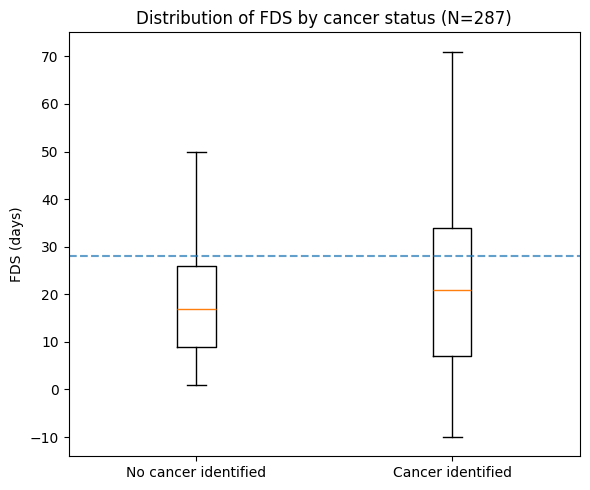

In [23]:
# --- 1. Prepare data ---
df_plot = df.copy()

# Binary cancer status
status = df_plot["CancerStatus"].fillna("")
df_plot["CancerStatus_binary"] = np.where(
    status.str.contains("No new cancer diagnosis identified", case=False, na=False),
    "No cancer identified",
    "Cancer identified"
)

# Drop missing FDS
df_plot = df_plot.dropna(subset=["FDS_days", "CancerStatus_binary"])

# --- 2. Summary statistics ---
summary = (
    df_plot
    .groupby("CancerStatus_binary")["FDS_days"]
    .median()
    .reindex(["No cancer identified", "Cancer identified"])
)

counts = df_plot["CancerStatus_binary"].value_counts()

# --- 3. Bar plot ---
plt.figure(figsize=(6, 5))

plt.bar(summary.index, summary.values)

# 28-day target
plt.axhline(28, linestyle="--", alpha=0.7, label="28-day FDS target")

# Annotate sample sizes
for i, cat in enumerate(summary.index):
    plt.text(
        i,
        summary.loc[cat] + 1,
        f"n={counts.get(cat, 0)}",
        ha="center",
        va="bottom"
    )

plt.ylabel("Median FDS (days)")
plt.title("FDS by cancer status (N={})".format(len(df_plot)))
plt.legend()
plt.tight_layout()
plt.show()

# --- 4. Optional: boxplot (distribution view) ---
plt.figure(figsize=(6, 5))

plt.boxplot(
    [
        df_plot.loc[df_plot["CancerStatus_binary"] == "No cancer identified", "FDS_days"],
        df_plot.loc[df_plot["CancerStatus_binary"] == "Cancer identified", "FDS_days"],
    ],
    tick_labels=["No cancer identified", "Cancer identified"],
    showfliers=False
)

plt.axhline(28, linestyle="--", alpha=0.7)
plt.ylabel("FDS (days)")
plt.title("Distribution of FDS by cancer status (N={})".format(len(df_plot)))
plt.tight_layout()
plt.show()


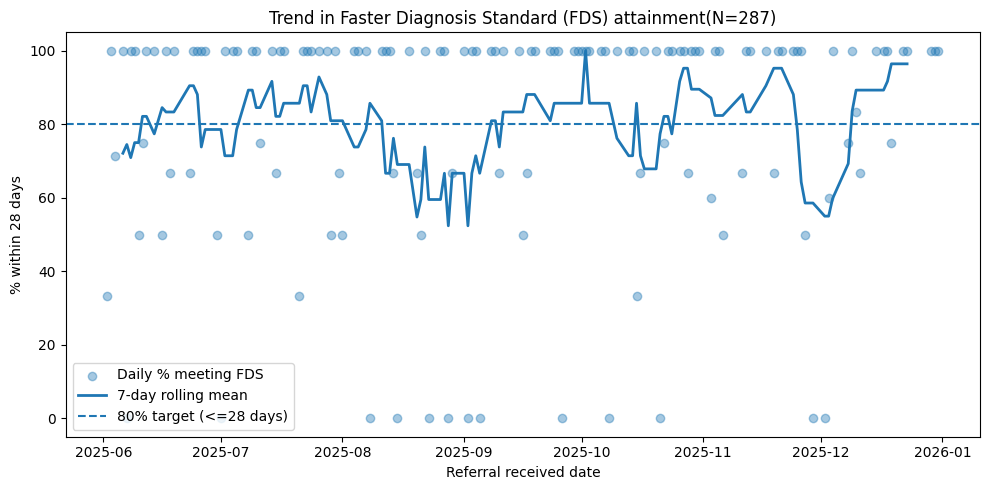

In [24]:
# % meeting FDS (<= 28 days)
daily_pct = (
    (df["FDS_days"] <= 28)
    .groupby(df["ReferralReceivedDate"])
    .mean()
    .mul(100)
    .sort_index()
)

# 7-day smoothing (I'd use mean here; median also fine)
rolling_pct = daily_pct.rolling(window=7, center=True).mean()

plt.figure(figsize=(10, 5))
plt.scatter(daily_pct.index, daily_pct.values, alpha=0.4, label="Daily % meeting FDS")
plt.plot(rolling_pct.index, rolling_pct.values, linewidth=2, label="7-day rolling mean")
plt.axhline(80, linestyle="--", label="80% target (<=28 days)")

plt.ylabel("% within 28 days")
plt.xlabel("Referral received date")
plt.title("Trend in Faster Diagnosis Standard (FDS) attainment(N={})".format(len(df)))

plt.legend()
plt.tight_layout()

plt.savefig("fds_attainment_trend.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
# explicit re 6 month period
start = df["ReferralReceivedDate"].min()
end = start + pd.DateOffset(months=6)

df6 = df[
    (df["ReferralReceivedDate"] >= start) &
    (df["ReferralReceivedDate"] < end)
]

midpoint = start + pd.DateOffset(months=3)

first_3m = df6[df6["ReferralReceivedDate"] < midpoint]
second_3m = df6[df6["ReferralReceivedDate"] >= midpoint]

summary = pd.DataFrame({
    "period": ["Months 1–3", "Months 4–6"],
    "n": [len(first_3m), len(second_3m)],
    "mean_FDS": [
        first_3m["FDS_days"].mean(),
        second_3m["FDS_days"].mean()
    ],
    "median_FDS": [
        first_3m["FDS_days"].median(),
        second_3m["FDS_days"].median()
    ],
    "pct_within_28": [
        (first_3m["FDS_days"] <= 28).mean() * 100,
        (second_3m["FDS_days"] <= 28).mean() * 100
    ]
})

summary

,period,n,mean_FDS,median_FDS,pct_within_28
0,Months 1–3,131,21.877863,18.0,77.099237
1,Months 4–6,118,19.550847,16.5,80.508475


In [26]:
first = first_3m["FDS_days"].dropna()
second = second_3m["FDS_days"].dropna()

first.describe()

count    131.000000
mean      21.877863
std       18.747317
min      -10.000000
25%        9.500000
50%       18.000000
75%       28.000000
max      122.000000
Name: FDS_days, dtype: float64

In [27]:
second.describe()

count    118.000000
mean      19.550847
std       14.266449
min        0.000000
25%        9.000000
50%       16.500000
75%       27.000000
max       71.000000
Name: FDS_days, dtype: float64

In [28]:
from scipy.stats import mannwhitneyu

u_stat, p_value = mannwhitneyu(
    first,
    second,
    alternative="two-sided"
)

u_stat, p_value # not a statistically significant difference

(np.float64(8191.5), np.float64(0.41534347970925034))

In [29]:
df6 = df6.copy()
df6["month"] = df6["ReferralReceivedDate"].dt.to_period("M")
monthly_summary = (
    df6
    .groupby("month")
    .agg(
        n=("FDS_days", "count"),
        mean_FDS=("FDS_days", "mean"),
        median_FDS=("FDS_days", "median"),
        pct_within_28=("FDS_days", lambda x: (x <= 28).mean() * 100),
    )
    .reset_index()
)

monthly_summary

,month,n,mean_FDS,median_FDS,pct_within_28
0,2025-06,49,23.204082,21.0,75.510204
1,2025-07,46,18.717391,14.5,82.608696
2,2025-08,34,24.529412,16.5,70.588235
3,2025-09,42,22.285714,18.0,80.952381
4,2025-10,42,17.809524,13.5,80.952381
5,2025-11,36,18.250000,17.0,80.555556


In [30]:
monthly_summary["period"] = [
    "Months 1–3" if i < 3 else "Months 4–6"
    for i in range(len(monthly_summary))
]

In [31]:
monthly_summary.sort_values(by="month")

,month,n,mean_FDS,median_FDS,pct_within_28,period
0,2025-06,49,23.204082,21.0,75.510204,Months 1–3
1,2025-07,46,18.717391,14.5,82.608696,Months 1–3
2,2025-08,34,24.529412,16.5,70.588235,Months 1–3
3,2025-09,42,22.285714,18.0,80.952381,Months 4–6
4,2025-10,42,17.809524,13.5,80.952381,Months 4–6
5,2025-11,36,18.250000,17.0,80.555556,Months 4–6


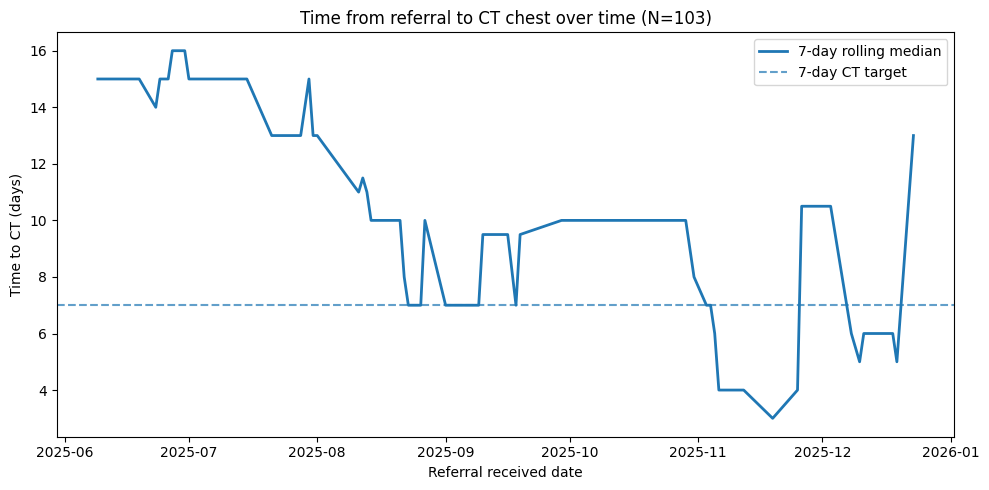

In [ ]:
# cancer pathway dataframe with CT Chest Exam Date added
df = rad

ct = df[df['ExamName'] == 'CT Chest'].sort_values(by='Exam_Date').drop_duplicates()[['patient_id', 'Exam_Date']] # CT Chests
ct.columns = ['patient_id', 'CT_Chest_Date']

df = cp

df = df.merge(
    ct,
    on="patient_id",
    how="left"
)

df["CT_Chest_Date"] = pd.to_datetime(
    df["CT_Chest_Date"],
    errors="coerce"
)
df["ReferralReceivedDate"] = pd.to_datetime(
    df["ReferralReceivedDate"],
    errors="coerce"
)

df = df.copy()
df['Time_to_ct_days'] = df['CT_Chest_Date'] - df['ReferralReceivedDate']

df['Time_to_ct_days']  = (
    df['Time_to_ct_days'] .dropna().astype(str)
    .str.replace(' days', '', regex=False)
    .astype(int)
)

df_ct = df.dropna(subset=["ReferralReceivedDate", "CT_Chest_Date", "Time_to_ct_days"])
df_ct = df_ct[df_ct["Time_to_ct_days"] >= 0]

daily = (
    df_ct
    .groupby(df_ct["ReferralReceivedDate"].dt.normalize())
    ["Time_to_ct_days"]
    .median()
    .sort_index()
)
weekly = daily.resample("W").median()
rolling = daily.rolling(window=7, center=True).median()  # 7-day smoothing

plt.figure(figsize=(10, 5))


plt.plot(
    rolling.index,
    rolling.values,
    linewidth=2,
    label="7-day rolling median"
)

plt.axhline(7, linestyle="--", alpha=0.7, label="7-day CT target")

plt.ylabel("Time to CT (days)")
plt.xlabel("Referral received date")
plt.title("Time from referral to CT chest over time (N={})".format(len(df_ct)))
plt.legend()
plt.tight_layout()
plt.savefig("referral_to_ct_trend1.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
df_ct["month"] = df_ct["ReferralReceivedDate"].dt.to_period("M")

monthly = (
    df_ct
    .groupby("month")
    .agg(
        n=("Time_to_ct_days", "count"),
        median_days=("Time_to_ct_days", "median"),
        mean_days=("Time_to_ct_days", "mean"),
        pct_within_7=("Time_to_ct_days", lambda x: (x <= 7).mean() * 100),
    )
    .reset_index()
)

monthly

In [ ]:
# don't want right-censoring bias (if we're having a look at incomplete pathways too)
last_referral_date = df["ReferralReceivedDate"].max()
cutoff_date = last_referral_date - pd.Timedelta(days=14)
df_ct = df[
    (df["ReferralReceivedDate"] <= cutoff_date)
].copy()

df_ct = df_ct.dropna(subset=["ReferralReceivedDate", "CT_Chest_Date", "Time_to_ct_days"])
df_ct = df_ct[df_ct["Time_to_ct_days"] >= 0]

daily = (
    df_ct
    .groupby(df_ct["ReferralReceivedDate"].dt.normalize())
    ["Time_to_ct_days"]
    .median()
    .sort_index()
)

weekly = daily.resample("W").median()
rolling = daily.rolling(window=7, center=True).median()  # 7-day smoothing

plt.figure(figsize=(10, 5))


plt.scatter(
    weekly.index,
    weekly.values,
    alpha=0.6,
    label="Weekly median"
)

plt.plot(
    rolling.values,
    linewidth=2,
    label="7-day rolling median"
)

plt.axhline(7, linestyle="--", alpha=0.7, label="7-day CT target")

plt.ylabel("Time to CT (days)")
plt.xlabel("Referral received date")
plt.title("Time from referral to CT chest over time (N={})".format(len(df_ct)))

plt.legend()
plt.tight_layout()
plt.savefig("referral_to_ct_trend2.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
df_ct["month"] = df_ct["ReferralReceivedDate"].dt.to_period("M")

monthly = (
    df_ct
    .groupby("month")
    .agg(
        n=("Time_to_ct_days", "count"),
        median_days=("Time_to_ct_days", "median"),
        mean_days=("Time_to_ct_days", "mean"),
        pct_within_7=("Time_to_ct_days", lambda x: (x <= 7).mean() * 100),
    )
    .reset_index()
)

monthly

In [ ]:
df = op

In [ ]:
# --- 1. Prep ---
df_op = df.copy()

df_op["Appointment_Date"] = pd.to_datetime(
    df_op["Appointment_Date"], errors="coerce"
)

# Keep outpatient attendances only (adjust if needed)
df_op = df_op[df_op["EncounterType"] == "Outpatient"]

# Drop rows without key info
df_op = df_op.dropna(subset=["patient_id", "Appointment_Date"])

# Month of attendance
df_op["month"] = df_op["Appointment_Date"].dt.to_period("M")

# --- 2. Count attendances per patient per month ---
per_patient_month = (
    df_op
    .groupby(["month", "patient_id"])
    .size()
    .reset_index(name="n_attendances")
)

# --- 3. Summarise across patients (this is the key step) ---
monthly_summary = (
    per_patient_month
    .groupby("month")
    .agg(
        n_patients=("patient_id", "nunique"),
        mean_attendances=("n_attendances", "mean"),
        median_attendances=("n_attendances", "median"),
    )
    .reset_index()
)

# Convert month to datetime for plotting
monthly_summary["month_dt"] = monthly_summary["month"].dt.to_timestamp()

monthly_summary

In [ ]:
df[(df['LocalSpecialtyDesc'] == 'Thoracic Medicine') & (df['EncounterType'] == 'Outpatient') & (df['FirstAttendDesc'] != 'Administrative Event')]['FirstAttendDesc'].value_counts()

In [ ]:
# --- Filter ---
# note we're not currently filtering by 'USC' appointment type
df_thor = df.copy()
df_thor["Appointment_Date"] = pd.to_datetime(df_thor["Appointment_Date"], errors="coerce")

df_thor = df_thor[
    (df_thor["LocalSpecialtyDesc"] == "Thoracic Medicine") &
    (df_thor["EncounterType"] == "Outpatient") &
    (df_thor["FirstAttendDesc"] != "Administrative Event")
].dropna(subset=["Appointment_Date", "FirstAttendDesc"])

# --- New vs Follow-up classification ---
df_thor["attendance_type"] = np.where(
    df_thor["FirstAttendDesc"].str.contains("First Attendance", case=False, na=False),
    "New",
    "Follow-up"
)

# --- Monthly counts ---
df_thor["month"] = df_thor["Appointment_Date"].dt.to_period("M")

monthly_counts = (
    df_thor
    .groupby(["month", "attendance_type"])
    .size()
    .unstack(fill_value=0)
)

# Ensure both columns exist even if a month has only one type
monthly_counts = monthly_counts.reindex(columns=["New", "Follow-up"], fill_value=0)

# --- Ratios / percentages ---
monthly_counts["total"] = monthly_counts["New"] + monthly_counts["Follow-up"]
monthly_counts["pct_new"] = (monthly_counts["New"] / monthly_counts["total"]).replace([np.inf, -np.inf], np.nan) * 100
monthly_counts["pct_followup"] = (monthly_counts["Follow-up"] / monthly_counts["total"]).replace([np.inf, -np.inf], np.nan) * 100
monthly_counts["ratio_new_to_followup"] = (monthly_counts["New"] / monthly_counts["Follow-up"].replace(0, np.nan))

# For plotting: convert PeriodIndex -> Timestamp index
monthly_counts["month_dt"] = monthly_counts.index.to_timestamp()

# If you want to inspect:
# print(monthly_counts.columns)
# display(monthly_counts.reset_index().head())

# --- Plot: % New vs % Follow-up ---
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_counts["month_dt"],
    monthly_counts["pct_new"],
    marker="o",
    label="New (%)"
)

plt.plot(
    monthly_counts["month_dt"],
    monthly_counts["pct_followup"],
    marker="o",
    linestyle="--",
    label="Follow-up (%)"
)

plt.ylabel("Percentage of OP attendances")
plt.xlabel("Month")
plt.title("Thoracic OP appointments: New vs Follow-up over time")
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

# --- Optional plot: New : Follow-up ratio ---
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_counts["month_dt"],
    monthly_counts["ratio_new_to_followup"],
    marker="o"
)

plt.axhline(1, linestyle="--", alpha=0.6, label="1:1 ratio")
plt.ylabel("New : Follow-up ratio")
plt.xlabel("Month")
plt.title("Ratio of new to follow-up thoracic OP appointments")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
monthly_counts

In [ ]:
# =========================
# SETTINGS
# =========================
SPECIALTY = "Thoracic Medicine"
ENCOUNTER_TYPE = "Outpatient"
EXCLUDE_FIRSTATTENDDESC = "Administrative Event"

# AttendDNACode mapping:
# 5 = Attended
# 6 = Late but seen (count as attended)
# 7 = Late and not seen (count as DNA)
# 3 = DNA
ATTENDED_CODES = {5, 6}
DNA_CODES = {3, 7}

MIN_RESOURCE_N = 5
OTHER_LABEL = "Other"

# =========================
# HELPERS
# =========================
def classify_new_followup(series):
    return np.where(
        series.fillna("").str.contains("First Attendance", case=False),
        "New",
        "Follow-up"
    )

def collapse_rare(series, min_n, other_label="Other"):
    s = series.fillna("Missing").astype(str)
    counts = s.value_counts()
    keep = counts[counts >= min_n].index
    return s.where(s.isin(keep), other_label)

# =========================
# 1) BASE FILTER
# =========================
df_thor = df.copy()

df_thor["Appointment_Date"] = pd.to_datetime(df_thor["Appointment_Date"], errors="coerce")
df_thor["AttendDnaCode"] = pd.to_numeric(df_thor["AttendDnaCode"], errors="coerce")

df_thor = df_thor[
    (df_thor["LocalSpecialtyDesc"] == SPECIALTY) &
    (df_thor["EncounterType"] == ENCOUNTER_TYPE) &
    (df_thor["FirstAttendDesc"] != EXCLUDE_FIRSTATTENDDESC)
].dropna(subset=["Appointment_Date", "FirstAttendDesc", "Resource"])

# =========================
# 2) CLASSIFICATIONS
# =========================
df_thor["attendance_type"] = classify_new_followup(df_thor["FirstAttendDesc"])

df_thor["month"] = df_thor["Appointment_Date"].dt.to_period("M")
df_thor["month_dt"] = df_thor["month"].dt.to_timestamp()

# Updated DNA definition (3 or 7)
df_thor["is_dna"] = df_thor["AttendDnaCode"].isin(DNA_CODES)

# Optional (handy later): attended definition (5 or 6)
df_thor["is_attended"] = df_thor["AttendDnaCode"].isin(ATTENDED_CODES)

# =========================
# 3) STANDARDISE RESOURCE NAMES
# =========================
resource_map = {
    "Respiratory Locum": "Callum, Jack",
    "Respiratory Locum 2": "Reynolds, Carl"
}

df_thor["Resource_std"] = (
    df_thor["Resource"]
    .astype(str)
    .str.strip()
    .replace(resource_map)
)

df_thor["Resource_collapsed"] = collapse_rare(
    df_thor["Resource_std"],
    MIN_RESOURCE_N,
    OTHER_LABEL
)

# =========================
# A) NEW vs FOLLOW-UP BY RESOURCE
# =========================
resource_mix = (
    df_thor
    .groupby(["Resource_collapsed", "attendance_type"])
    .size()
    .unstack(fill_value=0)
)

for col in ["New", "Follow-up"]:
    if col not in resource_mix.columns:
        resource_mix[col] = 0

resource_mix["total"] = resource_mix["New"] + resource_mix["Follow-up"]
resource_mix["pct_new"] = resource_mix["New"] / resource_mix["total"] * 100
resource_mix = resource_mix.sort_values("pct_new", ascending=False)

print("\nResource mix (New vs Follow-up):")
print(resource_mix)

plt.figure(figsize=(8, max(4, 0.35 * len(resource_mix))))
plt.barh(resource_mix.index, resource_mix["pct_new"])
plt.xlabel("% New attendances")
plt.title("Thoracic OP clinic mix by Resource")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# =========================
# B) DNA RATE BY RESOURCE
# =========================
dna_by_resource = (
    df_thor
    .groupby("Resource_collapsed")
    .agg(
        n_appointments=("is_dna", "size"),
        dna_rate=("is_dna", "mean")
    )
)

dna_by_resource["dna_rate"] *= 100
dna_by_resource = dna_by_resource.sort_values("dna_rate", ascending=False)

print("\nDNA rate by Resource:")
print(dna_by_resource)

plt.figure(figsize=(8, max(4, 0.35 * len(dna_by_resource))))
plt.barh(dna_by_resource.index, dna_by_resource["dna_rate"])
plt.xlabel("DNA rate (%)")
plt.title("DNA rate by Resource (Thoracic OP)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
dna_by_resource

In [ ]:
# =========================
# SETTINGS
# =========================
SPECIALTY = "Thoracic Medicine"
ENCOUNTER_TYPE = "Outpatient"
EXCLUDE_FIRSTATTENDDESC = "Administrative Event"

# AttendDNACode mapping:
# 5 = Attended
# 6 = Late but seen (count as attended)
# 7 = Late and not seen (count as DNA)
# 3 = DNA
ATTENDED_CODES = {5, 6}
DNA_CODES = {3, 7}

# Explicit resource mapping
resource_map = {
    "Respiratory Locum": "Callum, Jack",
    "Respiratory Locum 2": "Reynolds, Carl",
}

# Final set of Resources we want to analyse
resources_of_interest = {
    "Callum, Jack",
    "Reynolds, Carl",
    "Macavei, Raluca",
    "Bhowmik SPR",
}

# =========================
# 1) BASE FILTER
# =========================
df_dna = df.copy()

df_dna["Appointment_Date"] = pd.to_datetime(df_dna["Appointment_Date"], errors="coerce")
df_dna["AttendDnaCode"] = pd.to_numeric(df_dna["AttendDnaCode"], errors="coerce")

df_dna = df_dna[
    (df_dna["LocalSpecialtyDesc"] == SPECIALTY) &
    (df_dna["EncounterType"] == ENCOUNTER_TYPE) &
    (df_dna["FirstAttendDesc"] != EXCLUDE_FIRSTATTENDDESC)
].dropna(subset=["Appointment_Date", "Resource", "AppointmentType"])

# =========================
# 2) DNA FLAG (updated definition)
# =========================
df_dna["is_dna"] = df_dna["AttendDnaCode"].isin(DNA_CODES)

# Optional (handy later)
df_dna["is_attended"] = df_dna["AttendDnaCode"].isin(ATTENDED_CODES)

# =========================
# 3) MAP RESOURCES + RESTRICT TO INTEREST SET
# =========================
df_dna["Resource_mapped"] = (
    df_dna["Resource"]
    .astype(str)
    .str.strip()
    .replace(resource_map)
)

df_dna = df_dna[df_dna["Resource_mapped"].isin(resources_of_interest)]

# =========================
# 3b) CLEAN APPOINTMENT TYPE (prettier labels)
# =========================
df_dna["AppointmentType_clean"] = (
    df_dna["AppointmentType"]
    .astype(str)
    .str.replace("Thoracic Medicine", "", regex=False)
    .str.replace("Appointment", "", regex=False)
    .str.replace("HUH", "", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df_dna["AppointmentType_clean"] = (
    df_dna["AppointmentType_clean"]
    .str.replace("New Outpatient", "New", regex=False)
    .str.replace("Follow Up", "Follow-up", regex=False)
    .str.replace("Non Face-to-Face", "Non-F2F", regex=False)
    .str.replace("Non Face to Face", "Non-F2F", regex=False)
    .str.replace("Face to Face", "F2F", regex=False)
)

# =========================
# 4) DNA ANALYSIS BY RESOURCE × CLEANED APPOINTMENT TYPE
# =========================
dna_summary = (
    df_dna
    .groupby(["Resource_mapped", "AppointmentType_clean"])
    .agg(
        n_appointments=("is_dna", "size"),
        n_dna=("is_dna", "sum"),
        dna_rate=("is_dna", "mean"),
    )
    .reset_index()
)

dna_summary["dna_rate"] = (dna_summary["dna_rate"] * 100).round(1)

dna_summary["DNA"] = (
    dna_summary["n_dna"].astype(int).astype(str)
    + " / "
    + dna_summary["n_appointments"].astype(int).astype(str)
)
dna_summary = dna_summary.drop(columns=["n_dna", "n_appointments"])

dna_summary = dna_summary.rename(columns={
    "Resource_mapped": "Resource",
    "AppointmentType_clean": "Appointment type",
    "dna_rate": "DNA rate (%)"
}).sort_values(["Resource", "DNA rate (%)"], ascending=[True, False])

print("\nDNA analysis by Resource and AppointmentType (cleaned):")
print(dna_summary)

# =========================
# Optional: pivot to a wide, slide-friendly table
# =========================
dna_wide = dna_summary.pivot_table(
    index="Resource",
    columns="Appointment type",
    values="DNA rate (%)",
    aggfunc="first"
)

print("\nDNA rate (%) wide table:")
print(dna_wide)


In [ ]:
df = cp

df = df.merge(
    op,
    on="patient_id",
    how="right"
)

In [ ]:
df.groupby('Cancer Diagnosis')['LocalSpecialtyDesc'].value_counts(normalize=True)

In [ ]:
df = op

In [ ]:
# =========================
# SETTINGS
# =========================
SPECIALTY = "Thoracic Medicine"
ENCOUNTER_TYPE = "Outpatient"
EXCLUDE_FIRSTATTENDDESC = "Administrative Event"

# =========================
# 1) BASE FILTER
# =========================
df_thor = df.copy()

df_thor["Appointment_Date"] = pd.to_datetime(df_thor["Appointment_Date"], errors="coerce")
df_thor["AttendDnaCode"] = pd.to_numeric(df_thor["AttendDnaCode"], errors="coerce")

df_thor = df_thor[
    (df_thor["LocalSpecialtyDesc"] == SPECIALTY) &
    (df_thor["EncounterType"] == ENCOUNTER_TYPE) &
    (df_thor["FirstAttendDesc"] != EXCLUDE_FIRSTATTENDDESC)
].dropna(subset=["Appointment_Date", "FirstAttendDesc", "Resource"])

# cancer pathway dataframe with CT Chest Exam Date and First Appointment added
df = rad

ct = df[df['ExamName'] == 'CT Chest'].sort_values(by='Exam_Date').drop_duplicates()[['patient_id', 'Exam_Date']] # CT Chests
ct.columns = ['patient_id', 'CT_Chest_Date']

df = cp

df = df.merge(
    ct,
    on="patient_id",
    how="left"
)

df = df.merge(
    df_thor,
    on="patient_id",
    how="left"
)


# =========================
# SETTINGS
# =========================
TIME_AXIS = "ReferralReceivedDate"   # or "Appointment_Date"
ROLLING_MONTHS = 3                  # set None to disable
POLICY_DATE = "2025-08-08"          # set None to disable vertical line

# =========================
# 1) COPY + PARSE DATES
# =========================
df_ct = df.copy()

date_cols = ["ReferralReceivedDate", "CT_Chest_Date", "Appointment_Date"]
for col in date_cols:
    if col in df_ct.columns:
        df_ct[col] = pd.to_datetime(df_ct[col], errors="coerce")

# =========================
# 2) FILTER TO PEOPLE WITH BOTH CT + APPOINTMENT
# =========================
df_ct = df_ct.dropna(subset=["patient_id", "CT_Chest_Date", "Appointment_Date"])

# =========================
# 3) DEDUPE: EARLIEST APPOINTMENT PER NHS NUMBER (KEEP WHOLE ROW)
# =========================
df_ct = (
    df_ct.sort_values(["patient_id", "Appointment_Date"])
         .drop_duplicates("patient_id", keep="first")
         .reset_index(drop=True)
)

# =========================
# 4) FLAG: CT BEFORE APPOINTMENT
# =========================
df_ct["ct_before_appt"] = df_ct["CT_Chest_Date"] < df_ct["Appointment_Date"]

# =========================
# 5) CHOOSE TIME AXIS + MAKE MONTH
# =========================
if TIME_AXIS not in df_ct.columns:
    raise KeyError(f"{TIME_AXIS} not found in df. Choose from: {list(df_ct.columns)}")

df_ct = df_ct.dropna(subset=[TIME_AXIS])
df_ct["month"] = df_ct[TIME_AXIS].dt.to_period("M").dt.to_timestamp()

# =========================
# 6) MONTHLY SUMMARY
# =========================
monthly = (
    df_ct.groupby("month")
         .agg(
             n=("ct_before_appt", "size"),
             pct_ct_before_appt=("ct_before_appt", "mean")
         )
         .reset_index()
)
monthly["pct_ct_before_appt"] *= 100

# Optional rolling smoothing
if ROLLING_MONTHS and ROLLING_MONTHS > 1:
    monthly["rolling_pct"] = monthly["pct_ct_before_appt"].rolling(ROLLING_MONTHS, center=True).mean()
else:
    monthly["rolling_pct"] = pd.NA

# =========================
# 7) PLOT
# =========================
plt.figure(figsize=(10, 5))

plt.plot(
    monthly["month"],
    monthly["pct_ct_before_appt"],
    marker="o",
    label="CT before appointment (%)"
)

if monthly["rolling_pct"].notna().any():
    plt.plot(
        monthly["month"],
        monthly["rolling_pct"],
        linewidth=2,
        linestyle="--",
        label=f"{ROLLING_MONTHS}-month rolling average"
    )

# Optional policy line
if POLICY_DATE:
    policy_dt = pd.to_datetime(POLICY_DATE)
    plt.axvline(policy_dt, linestyle="--", linewidth=2, alpha=0.7, label=f"Policy ({policy_dt.date()})")

plt.ylim(0, 100)
plt.ylabel("Percentage (%)")
plt.xlabel(f"Month of {TIME_AXIS}")
plt.title("CT chest occurring before first outpatient appointment \n for patients with a CT Chest and an appointment after referral (N={})".format(len(df_ct)))
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 8) OUTPUT TABLE (DENOMINATORS MATTER!)
# =========================
monthly.sort_values("month")

In [ ]:
cp['patient_id'].value_counts().values # one person has 3 pathways in 6 months

In [ ]:
# =========================
# SETTINGS
# =========================
POLICY_DATE = pd.to_datetime("2025-08-08")

# =========================
# 1) PREP CANCER PATHWAYS (CREATE PATHWAY_ID)
# =========================
cp2 = cp.copy()

cp2["ReferralReceivedDate"] = pd.to_datetime(cp2["ReferralReceivedDate"], errors="coerce")
cp2["FDS_Pathway_End_Date"] = pd.to_datetime(cp2["FDS_Pathway_End_Date"], errors="coerce")

# Keep completed pathways only
cp2 = cp2.dropna(subset=["patient_id", "ReferralReceivedDate", "FDS_Pathway_End_Date"]).copy()

# Pre vs Post SOP by referral date
cp2["period"] = np.where(cp2["ReferralReceivedDate"] < POLICY_DATE, "Pre-SOP", "Post-SOP")

# Create a unique pathway identifier so repeat referrals are not collapsed
# (Uses key pathway timestamps; adds CareId if present to strengthen uniqueness)
key_cols = ["patient_id", "ReferralReceivedDate", "FDS_Pathway_End_Date"]
if "CareId" in cp2.columns:
    key_cols = ["CareId"] + key_cols

cp2["pathway_id"] = (
    cp2[key_cols]
    .astype(str)
    .agg("|".join, axis=1)
)

# Ensure pathway_id is unique even if two identical keys exist (rare)
cp2["pathway_id"] = cp2["pathway_id"] + "|" + cp2.groupby("pathway_id").cumcount().astype(str)

# =========================
# 2) PREP OP ATTENDANCES
# =========================
op2 = op.copy()
op2["Appointment_Date"] = pd.to_datetime(op2["Appointment_Date"], errors="coerce")

# Recommended filters (adjust if needed)
op2 = op2[
    (op2["EncounterType"] == "Outpatient") &
    (op2["FirstAttendDesc"] != "Administrative Event")
].dropna(subset=["patient_id", "Appointment_Date"])

# =========================
# 3) LINK OP ATTENDANCES TO PATHWAYS
# =========================
# Merge OP onto pathways by patient_id, then filter to appointments within each pathway window
op_pathway = op2.merge(
    cp2[["pathway_id", "patient_id", "ReferralReceivedDate", "FDS_Pathway_End_Date", "period"]],
    on="patient_id",
    how="inner"
)

op_pathway = op_pathway[
    (op_pathway["Appointment_Date"] >= op_pathway["ReferralReceivedDate"]) &
    (op_pathway["Appointment_Date"] <= op_pathway["FDS_Pathway_End_Date"])
]

# =========================
# 4) COUNT OP ATTENDANCES PER PATHWAY (INCLUDES REPEAT REFERRALS)
# =========================
op_counts = (
    op_pathway
    .groupby(["pathway_id", "period"])
    .size()
    .reset_index(name="op_attendances_per_pathway")
)

# Include pathways with zero OP attendances
all_pathways = cp2[["pathway_id", "period"]].drop_duplicates()

op_per_pathway_full = all_pathways.merge(
    op_counts,
    on=["pathway_id", "period"],
    how="left"
)

op_per_pathway_full["op_attendances_per_pathway"] = (
    op_per_pathway_full["op_attendances_per_pathway"].fillna(0).astype(int)
)

# =========================
# 5) SUMMARY PRE vs POST SOP (PATHWAYS, NOT UNIQUE PATIENTS)
# =========================
summary = (
    op_per_pathway_full
    .groupby("period")
    .agg(
        n_pathways=("pathway_id", "nunique"),
        mean_op_attendances=("op_attendances_per_pathway", "mean"),
        median_op_attendances=("op_attendances_per_pathway", "median"),
        pct_zero_op=("op_attendances_per_pathway", lambda x: (x == 0).mean() * 100),
    )
    .reset_index()
)

# Sanity check: should equal number of completed pathways
# print("Completed pathways (cp2 rows):", len(cp2))
# print("Pathways in summary:", summary["n_pathways"].sum())

display(
    summary
    .style
    .hide(axis="index")
)